# DAE Registration Quick Notebook

This notebook is the small public DAE example for `EOptInterface.jl`.

Its purpose is narrow and practical:
- show a tiny MTK system that stays a DAE after `structural_simplify(...)`;
- show how `register_daesystem(...)` is called;
- compare several supported time-stepping methods on the same DAE;
- save the results for later inspection.

This is not a full MPC notebook.
It is a registration-layer notebook.


In [7]:
using Pkg

repo_root = isdir(joinpath(pwd(), "src")) ? pwd() : normpath(joinpath(pwd(), ".."))
examples_env = joinpath(repo_root, "examples")
examples_project = joinpath(examples_env, "Project.toml")
generated_dir = joinpath(repo_root, "examples", "generated")
style_path = joinpath(repo_root, "notebooks", "eoi_publication_plots.jl")

# Set this to true only when bootstrapping a fresh examples environment.
bootstrap_examples_env = false

if Base.active_project() != examples_project
    Pkg.activate(examples_env; io=devnull)
end

if bootstrap_examples_env || !isfile(joinpath(examples_env, "Manifest.toml"))
    Pkg.instantiate(; io=devnull)
end

using CSV, DataFrames, Plots

include(style_path)
apply_eoi_publication_style!()


## Re-run The DAE Example

This cell runs `examples/dae_registration_demo.jl`.

The model is intentionally small:
- `D(x) = -x + z + u`
- `0 = z + sin(z) - x`

The second equation is implicit.
That is the key feature.
It prevents the algebraic part from disappearing during simplification, so the example remains a real DAE test case.


In [8]:
rerun_demo = true

example_script = joinpath(repo_root, "examples", "dae_registration_demo.jl")

if rerun_demo
    cmd = `$(Base.julia_cmd()) --project=$(examples_env) $example_script`
    run(cmd)
end


  Activating project at `/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples`



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Saved DAE demo outputs to:
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/dae_registration_structure_summary.csv
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/dae_registration_equations.csv
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/dae_registration_integrator_summary.csv
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EO

Process(`/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/bin/julia -C native -J/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/lib/julia/sys.dylib -g1 --color=yes '--project=/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/dae_registration_demo.jl'`, ProcessExited(0))

In [9]:
structure_path = joinpath(generated_dir, "dae_registration_structure_summary.csv")
equations_path = joinpath(generated_dir, "dae_registration_equations.csv")
integrator_path = joinpath(generated_dir, "dae_registration_integrator_summary.csv")
trajectory_path = joinpath(generated_dir, "dae_registration_trajectories.csv")

for path in (structure_path, equations_path, integrator_path, trajectory_path)
    isfile(path) || error("Missing $(path). Run the example cell first.")
end

structure_summary = CSV.read(structure_path, DataFrame)
equation_rows = CSV.read(equations_path, DataFrame)
integrator_summary = CSV.read(integrator_path, DataFrame)
trajectories = CSV.read(trajectory_path, DataFrame)

structure_summary


Row,system,diff_eq_count,alg_eq_count,unknown_count,equation_count
,String15,Int64,Int64,Int64,Int64
1,original,1,1,2,2
2,simplified,1,1,2,2


## Structure Check

This table is the first thing to inspect.
It answers one simple question:
"Did the model stay a DAE after simplification?"

If the simplified system still has both:
- a differential equation;
- an algebraic equation;
then the test case is doing its job.


In [10]:
equation_rows


Row,system,equation_index,lhs_type,equation
,String15,Int64,String15,String
1,original,1,differential,Differential(t)(x(t)) ~ u - x(t) + z(t)
2,original,2,algebraic,0 ~ -x(t) + sin(z(t)) + z(t)
3,simplified,1,algebraic,0 ~ -x(t) + sin(z(t)) + z(t)
4,simplified,2,differential,Differential(t)(x(t)) ~ u - x(t) + z(t)


In [11]:
integrator_summary


Row,integrator,termination_status,primal_status,objective,variable_count,constraint_count,x_final,z_final,u_first,u_last
,String7,String15,String15,Float64,Int64,Int64,Float64,Float64,Float64,Float64
1,IE,LOCALLY_SOLVED,FEASIBLE_POINT,1.10602,33,24,0.8,0.405511,2.0,5.33799e-16
2,RK4,LOCALLY_SOLVED,FEASIBLE_POINT,1.00334,63,54,0.8,0.405511,2.0,5.05737e-14
3,IRK4,LOCALLY_SOLVED,FEASIBLE_POINT,1.00334,73,64,0.8,0.405511,2.0,5.05733e-14


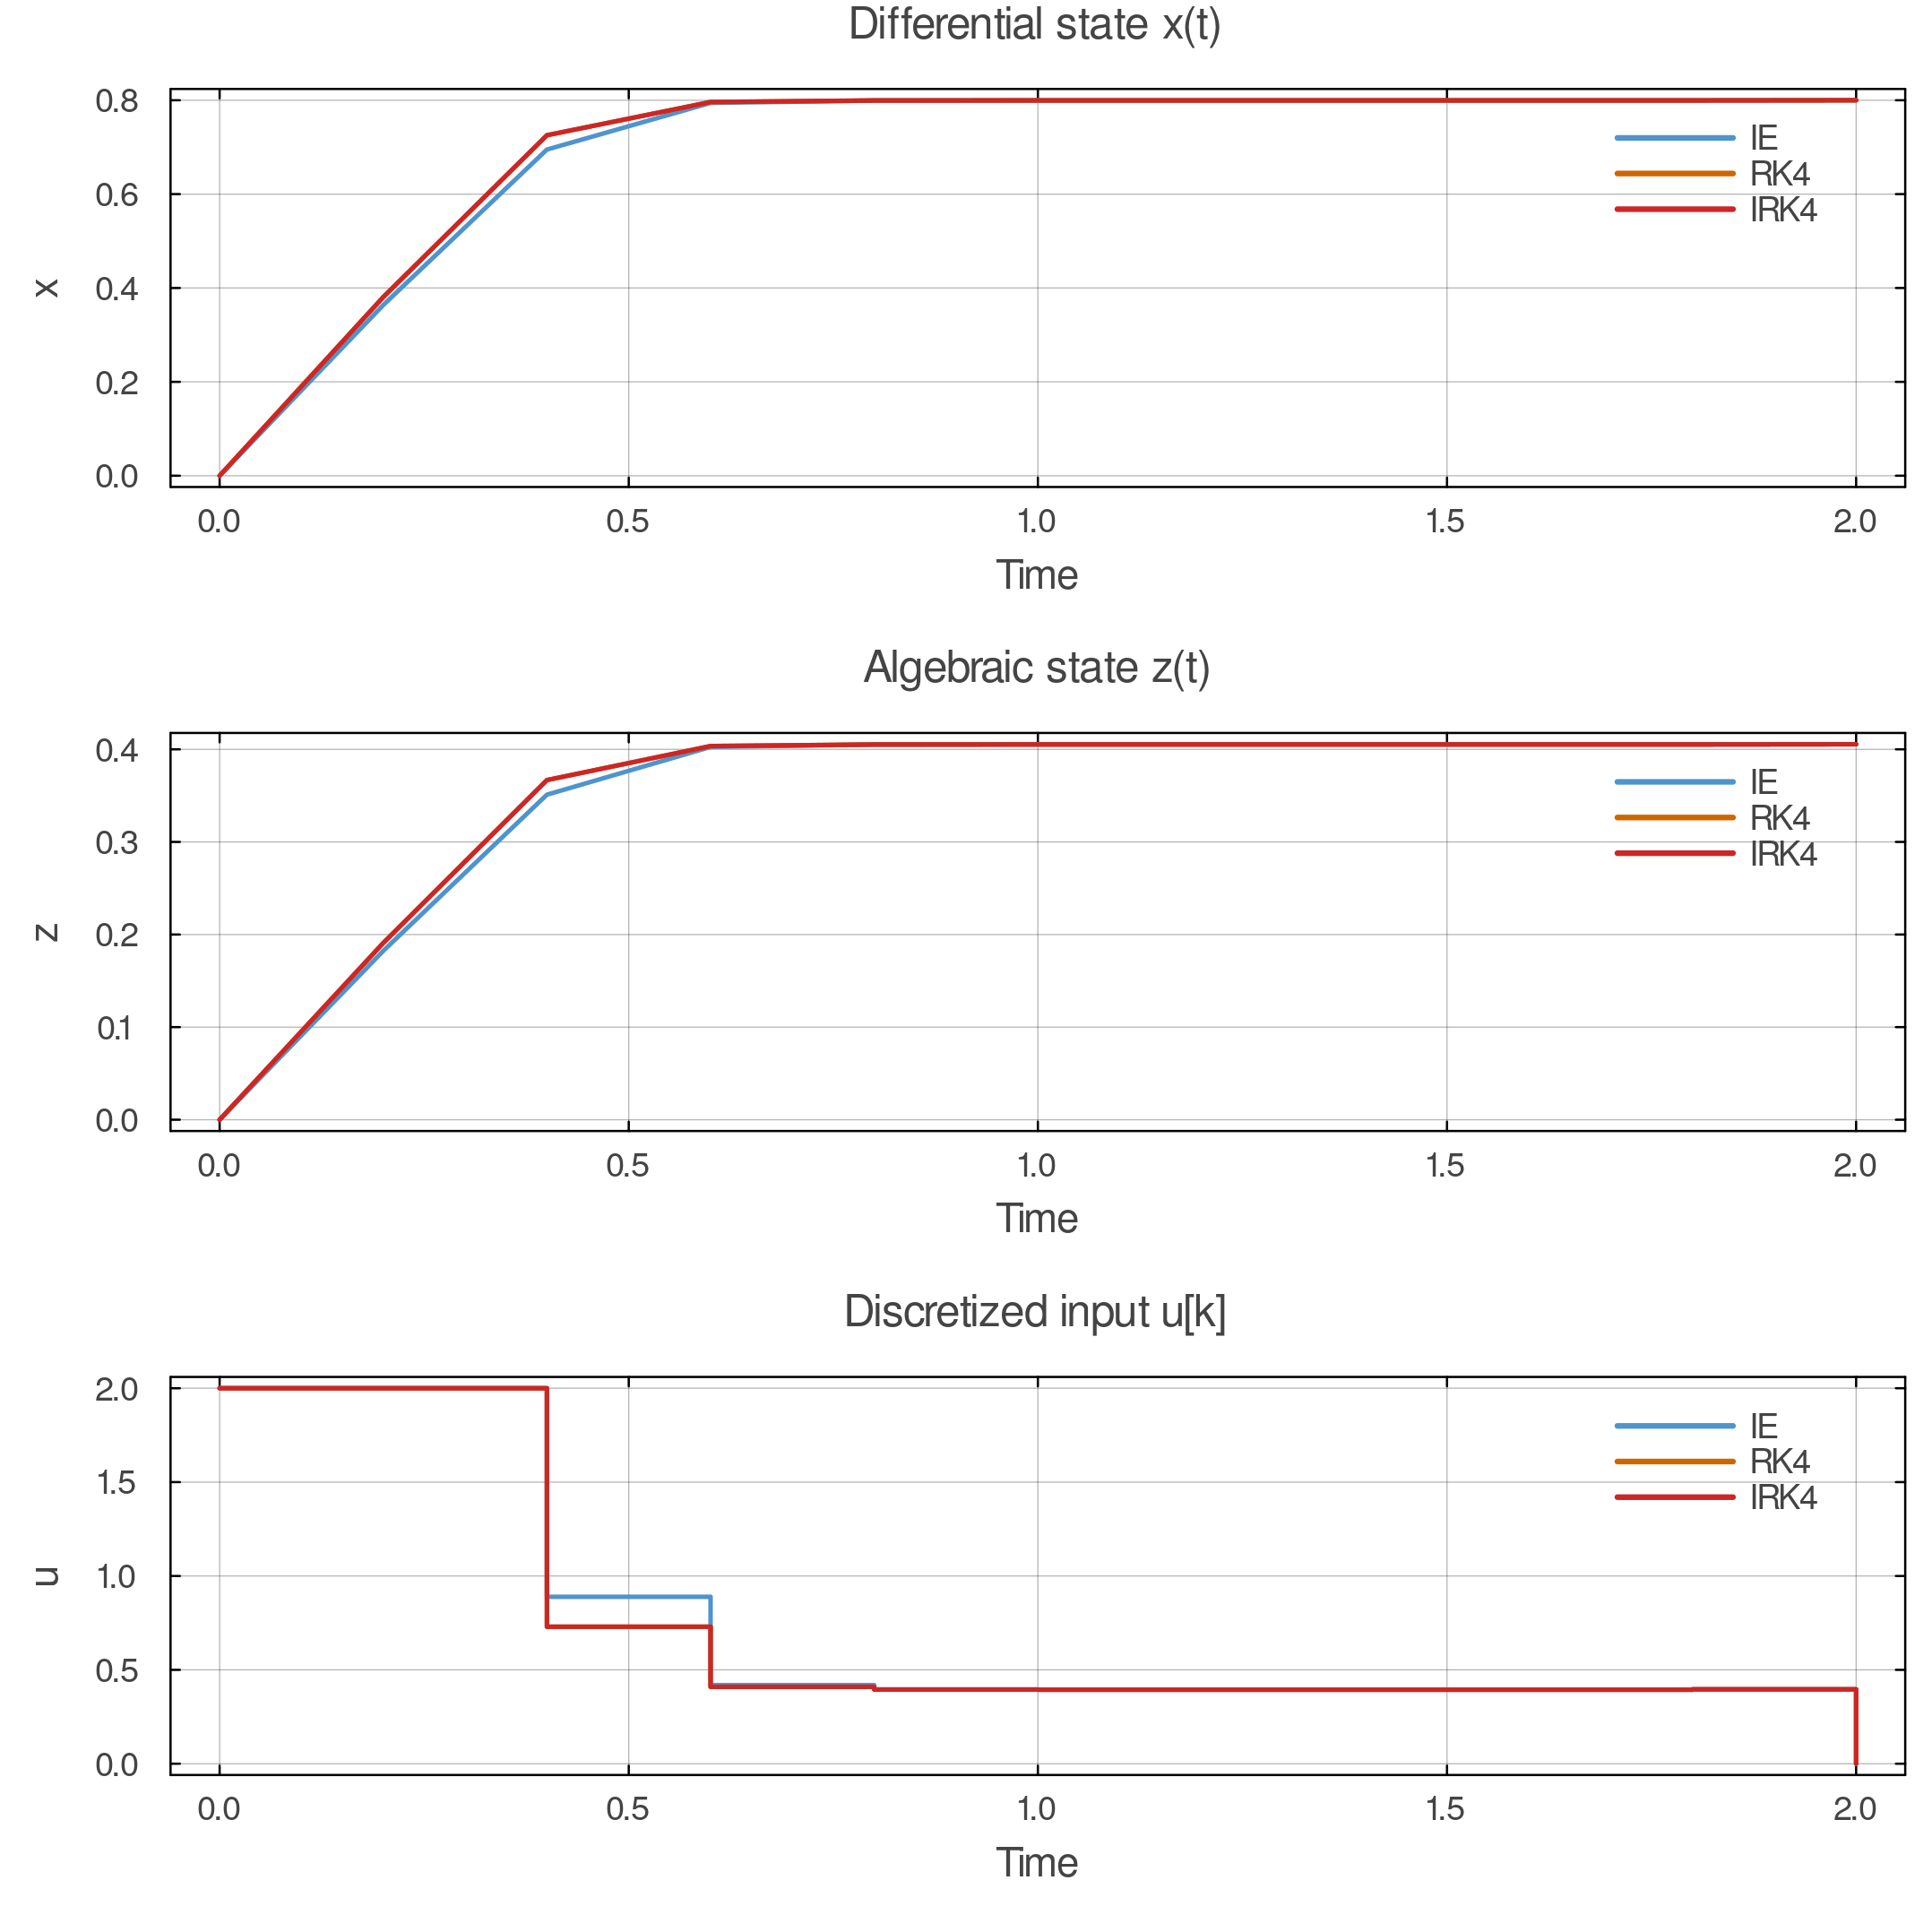

In [12]:
p_x = plot(title = "Differential state x(t)", xlabel = "Time", ylabel = "x")
p_z = plot(title = "Algebraic state z(t)", xlabel = "Time", ylabel = "z")
p_u = plot(title = "Discretized input u[k]", xlabel = "Time", ylabel = "u")

for integrator in unique(trajectories.integrator)
    sub = trajectories[trajectories.integrator .== integrator, :]
    plot!(p_x, sub.time, sub.x, label = integrator)
    plot!(p_z, sub.time, sub.z, label = integrator)
    plot!(p_u, sub.time, sub.u, label = integrator, seriestype = :steppost)
end

plot(p_x, p_z, p_u, layout = (3, 1), size = (980, 980))


dae_plot_registration_triplet(trajectories)
